# Learned Width Mapping Across Candidate Models

This notebook answers a narrower question than the trajectory PDF: for each
learning candidate model, what learned prior width does the model assign to
each true block prior width (`10`, `20`, `40`, `80` deg)?

The mapping is not forced to be identity. If true `40 deg` blocks are learned as
about `30 deg`, that is reported directly as the model's empirical calibration.


## Method

- Replay each saved fitted learning model over each participant's real trial
  sequence.
- Join the model's trial-level `believed_sd` to the experiment labels.
- Split each session/run block into early, middle, and late thirds.
- Use the late third as the default mapping phase, because the belief is updated
  after feedback and therefore lags block boundaries.
- Aggregate first within subject, then across subjects, to avoid treating every
  trial as an independent participant.

Non-learning models such as `switch` are excluded from learned-width mapping
because they have no trial-level learned prior state.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
HIERARCHICAL_ROOT = HERE.parents[1]
sys.path.insert(0, str(HIERARCHICAL_ROOT))

from observers import api
from observers.comparison.registry import ALL_MODELS, build_registry

DATA_CSV = HIERARCHICAL_ROOT / "data" / "data01_direction4priors.csv"
RESULTS_DIR = HERE / "results"
FIGURES_DIR = HERE / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SUBJECTS = api.subjects_with_data()
PRIOR_STDS = [10, 20, 40, 80]
COHERENCES = [0.06, 0.12, 0.24]
MAPPING_PHASE = os.environ.get("HB_MAPPING_PHASE", "late")
FORCE_REPLAY = os.environ.get("HB_FORCE_REPLAY", "0") == "1"

registry = build_registry(ALL_MODELS)
learning_candidates = []
excluded = []
for model in ALL_MODELS:
    spec = registry[model]
    fitted = api.fitted_subjects(model)
    if spec.learns and fitted:
        learning_candidates.append(model)
    else:
        excluded.append({"model": model, "learns": spec.learns, "n_fitted_subjects": len(fitted)})

print("learning candidates:", learning_candidates)
display(pd.DataFrame(excluded))


learning candidates: ['hb_adaptive', 'hb_rachel', 'hb_salma', 'recombined', 'hierarchical_online']


,model,learns,n_fitted_subjects
0,switch,False,12
1,basic_bayes,False,0
2,reliability_mixture,True,0


In [2]:
def load_aligned_design(subject_id: int) -> pd.DataFrame:
    df = pd.read_csv(DATA_CSV)
    df = (
        df.loc[df["subject_id"].eq(subject_id)]
        .sort_values(["subject_id", "session_id", "run_id", "trial_index"], kind="mergesort")
        .reset_index(drop=True)
    )
    keep = df[
        [
            "subject_id",
            "session_id",
            "run_id",
            "trial_index",
            "motion_direction",
            "motion_coherence",
            "prior_std",
        ]
    ].copy()
    keep["chronological_trial"] = np.arange(1, len(keep) + 1)
    keep["block_key"] = (
        keep["subject_id"].astype(str)
        + "_s"
        + keep["session_id"].astype(str)
        + "_r"
        + keep["run_id"].astype(str)
    )
    block_pos = keep.groupby("block_key").cumcount()
    block_n = keep.groupby("block_key")["trial_index"].transform("size")
    frac = (block_pos + 0.5) / block_n
    keep["block_trial_position"] = block_pos + 1
    keep["block_n_trials"] = block_n
    keep["block_phase"] = np.select(
        [frac < 1.0 / 3.0, frac < 2.0 / 3.0],
        ["early", "middle"],
        default="late",
    )
    return keep


def replay_candidate(model: str, subject_id: int) -> pd.DataFrame:
    design = load_aligned_design(subject_id)
    trajectory = api.belief_trajectory(model, subject_id).reset_index(drop=True)
    if len(trajectory) != len(design):
        raise ValueError(
            f"{model} subject {subject_id}: trajectory length {len(trajectory)} "
            f"does not match design length {len(design)}"
        )
    out = pd.concat([design, trajectory.drop(columns=["trial"], errors="ignore")], axis=1)
    out["model"] = model
    out["model_label"] = registry[model].label
    return out


def summarize_mapping(trials: pd.DataFrame) -> pd.DataFrame:
    grouped = trials.groupby(
        ["model", "model_label", "subject_id", "motion_coherence", "prior_std", "block_phase"],
        observed=True,
    )
    return grouped.agg(
        n_trials=("believed_sd", "size"),
        mean_believed_sd=("believed_sd", "mean"),
        median_believed_sd=("believed_sd", "median"),
        p25_believed_sd=("believed_sd", lambda x: float(np.percentile(x, 25))),
        p75_believed_sd=("believed_sd", lambda x: float(np.percentile(x, 75))),
        mean_believed_alpha=(
            "believed_alpha",
            lambda x: float(np.nanmean(x)) if np.isfinite(x).any() else np.nan,
        ),
    ).reset_index()


In [3]:
subject_condition_path = RESULTS_DIR / "hb_learned_width_mapping_subject_condition_phase.csv"
overall_path = RESULTS_DIR / "hb_learned_width_mapping_overall.csv"
coherence_path = RESULTS_DIR / "hb_learned_width_mapping_by_coherence.csv"
trial_cache_path = RESULTS_DIR / "hb_learned_width_mapping_trial_cache.parquet"

started = perf_counter()
if FORCE_REPLAY or not subject_condition_path.exists():
    rows = []
    for model in learning_candidates:
        fitted_subjects = sorted(set(api.fitted_subjects(model)).intersection(SUBJECTS))
        for subject_id in fitted_subjects:
            one = replay_candidate(model, subject_id)
            rows.append(one)
            print(f"replayed {model} subject {subject_id}: {len(one)} trials")
    trial_level = pd.concat(rows, ignore_index=True)
    subject_condition = summarize_mapping(trial_level)
    subject_condition.to_csv(subject_condition_path, index=False)
else:
    subject_condition = pd.read_csv(subject_condition_path)
    print(f"loaded cached subject-condition mapping: {subject_condition_path}")

late = subject_condition[subject_condition["block_phase"].eq(MAPPING_PHASE)].copy()
if late.empty:
    raise ValueError(f"No rows found for MAPPING_PHASE={MAPPING_PHASE!r}")

subject_prior = (
    late.assign(weighted_sd=late["mean_believed_sd"] * late["n_trials"])
    .groupby(["model", "model_label", "subject_id", "prior_std"], observed=True)
    .agg(
        n_trials=("n_trials", "sum"),
        learned_sd_sum=("weighted_sd", "sum"),
    )
    .reset_index()
)
subject_prior["learned_sd"] = subject_prior["learned_sd_sum"] / subject_prior["n_trials"]

overall = (
    subject_prior.groupby(["model", "model_label", "prior_std"], observed=True)
    .agg(
        n_subjects=("subject_id", "nunique"),
        mean_learned_sd=("learned_sd", "mean"),
        median_learned_sd=("learned_sd", "median"),
        sd_across_subjects=("learned_sd", "std"),
    )
    .reset_index()
)
overall["sem_learned_sd"] = overall["sd_across_subjects"] / np.sqrt(overall["n_subjects"])
overall["mapping_error_deg"] = overall["mean_learned_sd"] - overall["prior_std"]
overall["mapping_ratio"] = overall["mean_learned_sd"] / overall["prior_std"]
overall["phase"] = MAPPING_PHASE
overall = overall.sort_values(["model", "prior_std"]).reset_index(drop=True)
overall.to_csv(overall_path, index=False)

by_coherence_subject = (
    late.rename(columns={"motion_coherence": "coherence"})
    .groupby(["model", "model_label", "subject_id", "coherence", "prior_std"], observed=True)
    .agg(n_trials=("n_trials", "sum"), learned_sd=("mean_believed_sd", "mean"))
    .reset_index()
)
by_coherence = (
    by_coherence_subject.groupby(["model", "model_label", "coherence", "prior_std"], observed=True)
    .agg(
        n_subjects=("subject_id", "nunique"),
        mean_learned_sd=("learned_sd", "mean"),
        sd_across_subjects=("learned_sd", "std"),
    )
    .reset_index()
)
by_coherence["sem_learned_sd"] = by_coherence["sd_across_subjects"] / np.sqrt(by_coherence["n_subjects"])
by_coherence["phase"] = MAPPING_PHASE
by_coherence.to_csv(coherence_path, index=False)

print(f"mapping phase: {MAPPING_PHASE}")
print(f"elapsed seconds: {perf_counter() - started:.1f}")
display(overall.round(2))


loaded cached subject-condition mapping: C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\results\hb_learned_width_mapping_subject_condition_phase.csv
mapping phase: late
elapsed seconds: 0.1


,model,model_label,prior_std,n_subjects,mean_learned_sd,median_learned_sd,sd_across_subjects,sem_learned_sd,mapping_error_deg,mapping_ratio,phase
0,hb_adaptive,HB-Adaptive,10,12,10.84,10.40,1.12,0.32,0.84,1.08,late
1,hb_adaptive,HB-Adaptive,20,12,17.12,17.13,0.48,0.14,-2.88,0.86,late
2,hb_adaptive,HB-Adaptive,40,12,23.02,22.57,1.76,0.51,-16.98,0.58,late
3,hb_adaptive,HB-Adaptive,80,12,25.25,25.25,1.29,0.37,-54.75,0.32,late
4,hb_rachel,HB-Rachel,10,12,11.14,10.29,2.38,0.69,1.14,1.11,late
5,hb_rachel,HB-Rachel,20,12,16.41,16.22,1.42,0.41,-3.59,0.82,late
6,hb_rachel,HB-Rachel,40,12,24.30,23.67,4.74,1.37,-15.70,0.61,late
7,hb_rachel,HB-Rachel,80,12,35.56,32.30,14.11,4.07,-44.44,0.44,late
8,hb_salma,HB-Salma,10,12,28.35,27.14,17.03,4.92,18.35,2.83,late
9,hb_salma,HB-Salma,20,12,38.71,39.31,13.72,3.96,18.71,1.94,late


## Mapping Plot

Each panel is one candidate model. Points show the late-block learned prior SD
for each true prior-SD candidate. The dotted line is identity (`learned = true`).
Deviation from the dotted line is the mapping/calibration error.


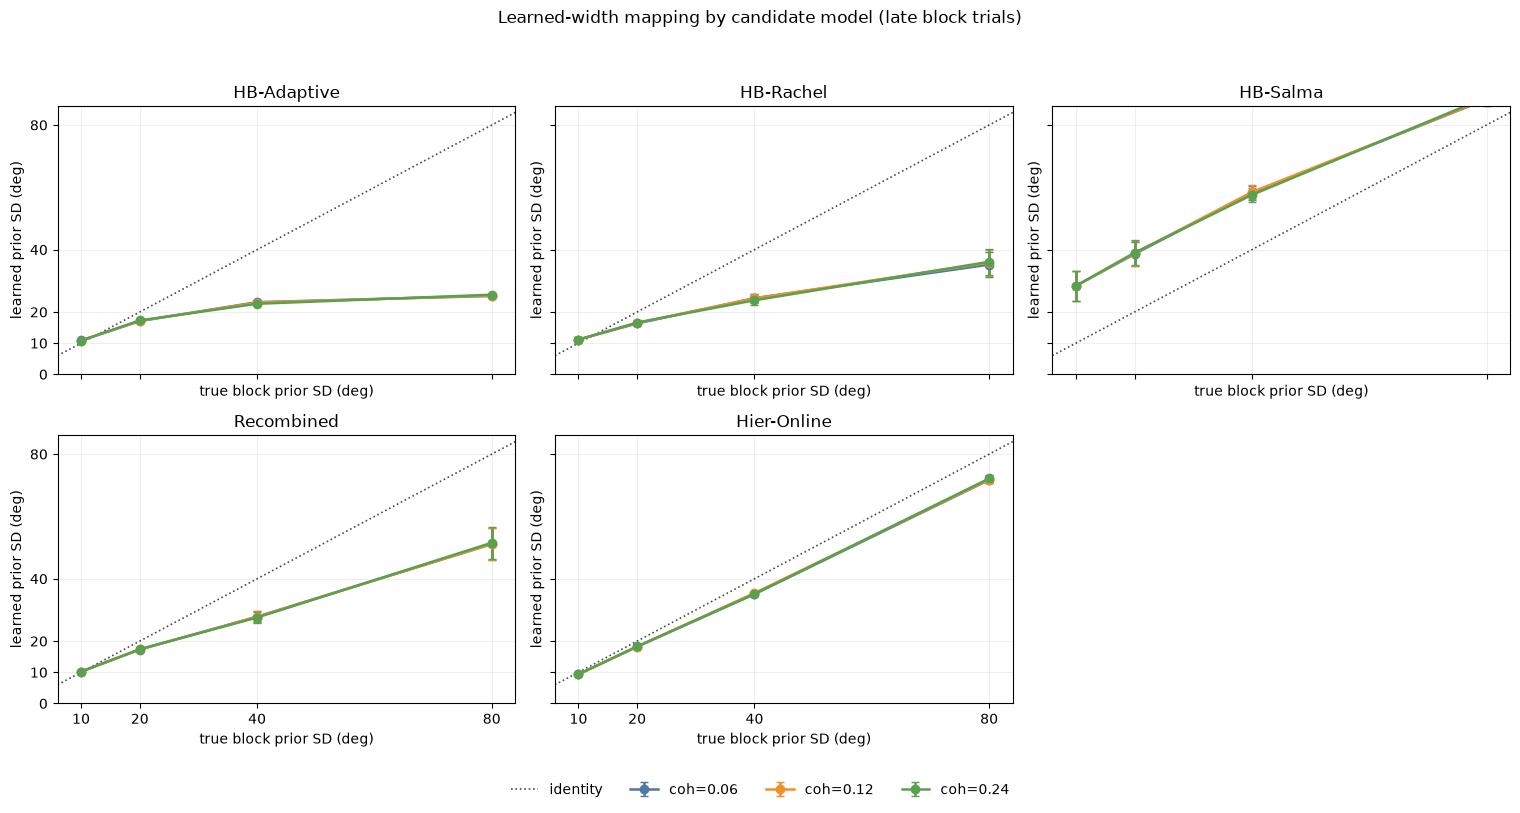

C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\figures\hb_learned_width_mapping_by_model.png


In [4]:
MODEL_ORDER = [m for m in learning_candidates if m in set(overall["model"])]
MODEL_COLORS = {
    "hb_adaptive": "#d1495b",
    "hb_rachel": "#edae49",
    "hb_salma": "#8e6c8a",
    "recombined": "#66a182",
    "hierarchical_online": "#3a7d44",
}
COHERENCE_COLORS = {0.06: "#4e79a7", 0.12: "#f28e2b", 0.24: "#59a14f"}

cols = min(3, len(MODEL_ORDER))
rows = int(np.ceil(len(MODEL_ORDER) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5.1 * cols, 4.0 * rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, model in zip(axes, MODEL_ORDER):
    model_rows = by_coherence[by_coherence["model"].eq(model)]
    for coherence in COHERENCES:
        rows_c = model_rows[np.isclose(model_rows["coherence"], coherence)].sort_values("prior_std")
        if rows_c.empty:
            continue
        ax.errorbar(
            rows_c["prior_std"],
            rows_c["mean_learned_sd"],
            yerr=rows_c["sem_learned_sd"],
            marker="o",
            lw=1.8,
            capsize=3,
            color=COHERENCE_COLORS[coherence],
            label=f"coh={coherence:g}",
        )
    ax.plot([0, 86], [0, 86], "k:", lw=1.2, alpha=0.7, label="identity")
    ax.set_title(registry[model].label)
    ax.set_xlim(6, 84)
    ax.set_ylim(0, 86)
    ax.set_xticks(PRIOR_STDS)
    ax.set_yticks([0, 10, 20, 40, 80])
    ax.grid(alpha=0.2)
    ax.set_xlabel("true block prior SD (deg)")
    ax.set_ylabel("learned prior SD (deg)")

for ax in axes[len(MODEL_ORDER):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:4], labels[:4], loc="lower center", bbox_to_anchor=(0.5, -0.015), ncol=4, frameon=False)
fig.suptitle(f"Learned-width mapping by candidate model ({MAPPING_PHASE} block trials)", y=0.985)
fig.tight_layout(rect=[0, 0.045, 1, 0.95])
mapping_plot = FIGURES_DIR / "hb_learned_width_mapping_by_model.png"
fig.savefig(mapping_plot, dpi=180, bbox_inches="tight")
plt.show()
print(mapping_plot)


## Mapping Matrix

This table-style figure collapses over coherence after subject-level averaging.
Read it as: true block SD -> model-implied learned SD.


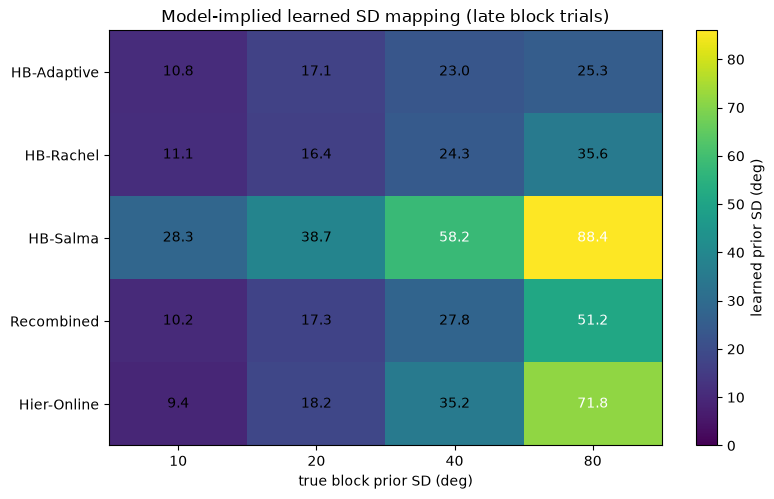

prior_std,10,20,40,80
model_label,,,,
HB-Adaptive,10.8,17.1,23.0,25.3
HB-Rachel,11.1,16.4,24.3,35.6
HB-Salma,28.3,38.7,58.2,88.4
Recombined,10.2,17.3,27.8,51.2
Hier-Online,9.4,18.2,35.2,71.8


C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\figures\hb_learned_width_mapping_matrix.png


In [5]:
matrix = (
    overall.pivot(index="model_label", columns="prior_std", values="mean_learned_sd")
    .reindex([registry[m].label for m in MODEL_ORDER])
)

fig, ax = plt.subplots(figsize=(8.2, 0.62 * len(matrix) + 2.0))
im = ax.imshow(matrix.to_numpy(), cmap="viridis", vmin=0, vmax=86, aspect="auto")
ax.set_xticks(np.arange(len(matrix.columns)), labels=[f"{c:g}" for c in matrix.columns])
ax.set_yticks(np.arange(len(matrix.index)), labels=matrix.index)
ax.set_xlabel("true block prior SD (deg)")
ax.set_title(f"Model-implied learned SD mapping ({MAPPING_PHASE} block trials)")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.iloc[i, j]
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="white" if value > 42 else "black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("learned prior SD (deg)")
fig.tight_layout()
matrix_plot = FIGURES_DIR / "hb_learned_width_mapping_matrix.png"
fig.savefig(matrix_plot, dpi=180, bbox_inches="tight")
plt.show()
display(matrix.round(1))
print(matrix_plot)


## Subject Spread

This plot shows whether the mapping is stable across participants or dominated
by a few subjects.


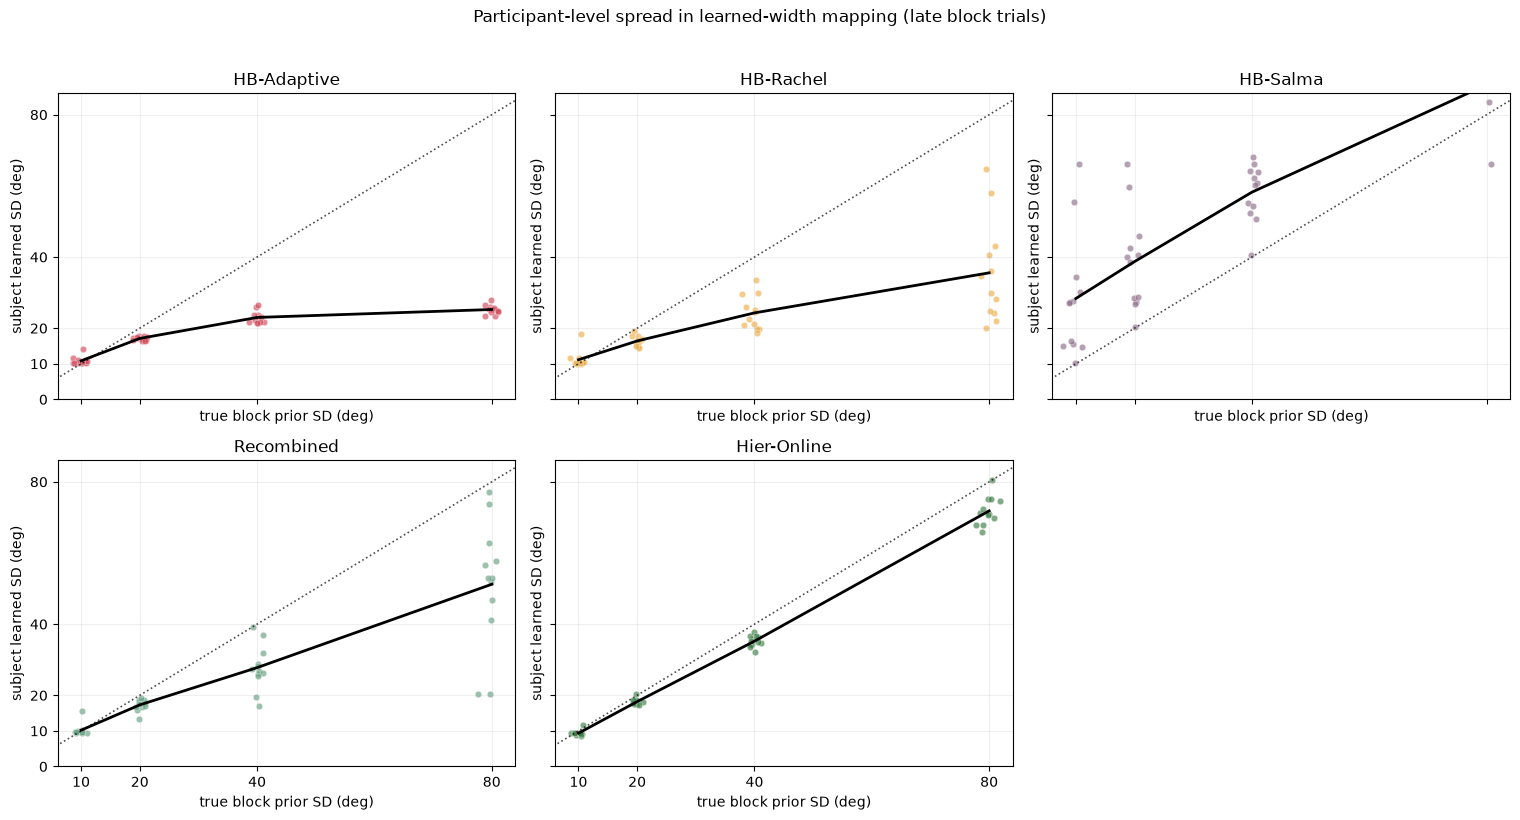

C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\figures\hb_learned_width_mapping_subject_spread.png


In [6]:
fig, axes = plt.subplots(rows, cols, figsize=(5.1 * cols, 4.0 * rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
rng = np.random.default_rng(20260723)

for ax, model in zip(axes, MODEL_ORDER):
    rows_m = subject_prior[subject_prior["model"].eq(model)].copy()
    for prior_std in PRIOR_STDS:
        vals = rows_m[rows_m["prior_std"].eq(prior_std)]["learned_sd"].to_numpy()
        jitter = rng.normal(0, 0.8, size=len(vals))
        ax.scatter(
            np.full(len(vals), prior_std) + jitter,
            vals,
            s=22,
            alpha=0.65,
            color=MODEL_COLORS.get(model, "0.4"),
            edgecolor="white",
            linewidth=0.35,
        )
    means = overall[overall["model"].eq(model)].sort_values("prior_std")
    ax.plot(means["prior_std"], means["mean_learned_sd"], "k-", lw=2.0, label="subject mean")
    ax.plot([0, 86], [0, 86], "k:", lw=1.2, alpha=0.7)
    ax.set_title(registry[model].label)
    ax.set_xlim(6, 84)
    ax.set_ylim(0, 86)
    ax.set_xticks(PRIOR_STDS)
    ax.set_yticks([0, 10, 20, 40, 80])
    ax.grid(alpha=0.2)
    ax.set_xlabel("true block prior SD (deg)")
    ax.set_ylabel("subject learned SD (deg)")

for ax in axes[len(MODEL_ORDER):]:
    ax.axis("off")

fig.suptitle(f"Participant-level spread in learned-width mapping ({MAPPING_PHASE} block trials)", y=1.02)
fig.tight_layout()
subject_plot = FIGURES_DIR / "hb_learned_width_mapping_subject_spread.png"
fig.savefig(subject_plot, dpi=180, bbox_inches="tight")
plt.show()
print(subject_plot)


## Specific Check: True 40 Deg Blocks

This is the direct answer to the visual concern: if the learned curve sits near
30 deg when the true prior label is 40 deg, the mapping table below quantifies
that gap.


In [7]:
true_40 = overall[overall["prior_std"].eq(40)].copy()
true_40 = true_40[
    [
        "model",
        "model_label",
        "n_subjects",
        "mean_learned_sd",
        "sem_learned_sd",
        "mapping_error_deg",
        "mapping_ratio",
    ]
].sort_values("mean_learned_sd")
display(true_40.round(2))


,model,model_label,n_subjects,mean_learned_sd,sem_learned_sd,mapping_error_deg,mapping_ratio
2,hb_adaptive,HB-Adaptive,12,23.02,0.51,-16.98,0.58
6,hb_rachel,HB-Rachel,12,24.30,1.37,-15.70,0.61
18,recombined,Recombined,12,27.78,1.79,-12.22,0.69
14,hierarchical_online,Hier-Online,12,35.22,0.45,-4.78,0.88
10,hb_salma,HB-Salma,12,58.21,2.27,18.21,1.46


## Interpretation Template

Use this wording in the presentation:

The learned width is a model-implied calibration of the nominal prior context,
not a forced copy of the experimenter's label. The important evidence is
monotonic mapping: learned width increases from true `10` to `80` deg. The
absolute values can be compressed. For example, a true `40 deg` prior can map to
about `30 deg` in a given model, meaning the fitted observer behaves as if that
context is narrower than the nominal generative label. We should therefore
report the mapping itself rather than claiming exact recovery of `10/20/40/80`.

When comparing candidates, prefer the model whose mapping is monotonic, stable
across subjects, and scientifically consistent with the model's update rule.
The `switch` model is a non-learning reference and should not be presented as a
learned-width trajectory.
